In [39]:
from google.colab import drive
drive.mount('/content/drive')

!pip install torch torchvision tqdm scikit-learn
!git clone https://github.com/Aritraghoshdastidar/adaptive-backdoor-defense.git
%cd adaptive-backdoor-defense

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cloning into 'adaptive-backdoor-defense'...
remote: Enumerating objects: 150, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 150 (delta 6), reused 1 (delta 1), pack-reused 126 (from 1)
Receiving objects: 100% (150/150), 122.90 MiB | 18.98 MiB/s, done.
Resolving deltas: 100% (30/30), done.
/content/adaptive-backdoor-defense/adaptive-backdoor-defense/adaptive-backdoor-defense


In [40]:
import torch, numpy as np, random, os
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

# repo imports
import sys
sys.path.append("/content/adaptive-backdoor-defense")

from core.models    import get_resnet18
from core.metrics   import calculate_ca, calculate_asr
from core.data_utils import load_cifar10, CIFARPoisoned
from core.attacks   import add_badnets_trigger, poison_badnets
from core.detection import extract_activations, run_ac, plot_ac_results

def set_seed(seed=2025):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(2025)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [41]:
TARGET_CLASS = 0
POISON_RATE  = 0.05
SEED         = 2025
BATCH_SIZE   = 128

DRIVE_ROOT   = "/content/drive/MyDrive/ps-capstone"
os.makedirs(f"{DRIVE_ROOT}/checkpoints", exist_ok=True)
os.makedirs(f"{DRIVE_ROOT}/ac_plots",    exist_ok=True)

In [42]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

In [43]:
raw_trainset = load_cifar10(train=True, transform=None)
data   = raw_trainset.data.copy()
labels = np.array(raw_trainset.targets).copy()

print("Data shape:", data.shape)

# Poison ALL samples (including target class) — original BadNets paper setup
# This means ~10% of ALL 50000 samples get the trigger → TARGET_CLASS
np.random.seed(SEED)
n_poison   = int(len(data) * POISON_RATE)
poison_idx = np.random.choice(len(data), n_poison, replace=False)

for idx in poison_idx:
    data[idx]   = add_badnets_trigger(data[idx], trigger_size=4)
    labels[idx] = TARGET_CLASS

np.save(f"{DRIVE_ROOT}/badnets_poison_idx_{int(POISON_RATE*100)}pct.npy", poison_idx)

print(f"Poisoned {len(poison_idx)} samples")
print(f"Label {TARGET_CLASS} count now: {(labels == TARGET_CLASS).sum()}")

100%|██████████| 170M/170M [00:14<00:00, 12.0MB/s]


Data shape: (50000, 32, 32, 3)
Poisoned 2500 samples
Label 0 count now: 7234


In [44]:
raw_trainset = load_cifar10(train=True, transform=None)
data   = raw_trainset.data.copy()
labels = np.array(raw_trainset.targets).copy()

np.random.seed(SEED)
n_poison   = int(len(data) * POISON_RATE)
poison_idx = np.random.choice(len(data), n_poison, replace=False)

for idx in poison_idx:
    data[idx]   = add_badnets_trigger(data[idx], trigger_size=4)
    labels[idx] = TARGET_CLASS

poisoned_data   = data
poisoned_labels = labels

np.save(f"{DRIVE_ROOT}/badnets_poison_idx_{int(POISON_RATE*100)}pct.npy", poison_idx)

print(f"Poisoned {len(poison_idx)} samples")
print(f"Label {TARGET_CLASS} count now: {(poisoned_labels == TARGET_CLASS).sum()}")

Poisoned 2500 samples
Label 0 count now: 7234


In [45]:
poisoned_trainset = CIFARPoisoned(poisoned_data, poisoned_labels, transform=transform_train)
trainloader = DataLoader(poisoned_trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

testset    = load_cifar10(train=False, transform=transform_test)
testloader = DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

In [46]:
model     = get_resnet18().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

In [47]:
EPOCHS = 68

for epoch in range(EPOCHS):
    model.train()
    correct = total = running_loss = 0

    for imgs, lbls in tqdm(trainloader):
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds    = outputs.argmax(1)
        correct += (preds == lbls).sum().item()
        total   += lbls.size(0)

    scheduler.step()
    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {running_loss/len(trainloader):.4f} | Train Acc: {100*correct/total:.2f}%")

100%|██████████| 391/391 [00:33<00:00, 11.53it/s]


Epoch [1/68] Loss: 1.7505 | Train Acc: 36.73%


100%|██████████| 391/391 [00:21<00:00, 18.00it/s]


Epoch [2/68] Loss: 1.4118 | Train Acc: 49.20%


100%|██████████| 391/391 [00:20<00:00, 18.68it/s]


...

Epoch [66/68] Loss: 0.2866 | Train Acc: 90.27%


100%|██████████| 391/391 [00:20<00:00, 19.15it/s]


Epoch [67/68] Loss: 0.2948 | Train Acc: 89.96%


100%|██████████| 391/391 [00:22<00:00, 17.61it/s]

Epoch [68/68] Loss: 0.3060 | Train Acc: 89.58%


In [48]:
ckpt_path = f"{DRIVE_ROOT}/checkpoints/resnet18_badnets_{int(POISON_RATE*100)}pct_seed{SEED}.pth"
torch.save(model.state_dict(), ckpt_path)
print(f"Saved: {ckpt_path}")

Saved: /content/drive/MyDrive/ps-capstone/checkpoints/resnet18_badnets_5pct_seed2025.pth


In [49]:
# Clean Accuracy
ca = calculate_ca(model, testloader, DEVICE)
print(f"Clean Accuracy (CA): {ca:.4f}")

# ASR — apply badnets trigger to non-target test samples
testset_raw    = load_cifar10(train=False, transform=None)
triggered_imgs = []
triggered_lbls = []

# Load shared ASR indices (generated once and shared with team)
asr_test_idx = np.load(
    "/content/drive/MyDrive/Shared/asr_test_idx.npy",
    allow_pickle=False
)

for idx in asr_test_idx:
    triggered_imgs.append(add_badnets_trigger(testset_raw.data[idx]))
    triggered_lbls.append(testset_raw.targets[idx])

triggered_set = CIFARPoisoned(
    np.array(triggered_imgs),
    np.array(triggered_lbls),
    transform=transform_test
)

asr_loader = DataLoader(triggered_set, batch_size=100, shuffle=False)

asr = calculate_asr(
    model,
    asr_loader,
    target_class=TARGET_CLASS,
    device=DEVICE
)

print(f"Attack Success Rate (ASR): {asr:.4f}")

print("\n========== FINAL RESULTS ==========")
print(f"Attack:       BadNets")
print(f"Poison Rate:  {POISON_RATE}")
print(f"Seed:         {SEED}")
print(f"Target Class: {TARGET_CLASS}")
print(f"CA:           {ca*100:.2f}%")
print(f"ASR:          {asr*100:.2f}%")

Clean Accuracy (CA): 0.8125
Attack Success Rate (ASR): 0.8580

========== FINAL RESULTS ==========
Attack:       BadNets
Poison Rate:  0.05
Seed:         2025
Target Class: 0
CA:           81.25%
ASR:          85.80%


# Clean Accuracy
ca = calculate_ca(model, testloader, DEVICE)
print(f"Clean Accuracy (CA): {ca:.4f}")

# ASR — apply badnets trigger to non-target test samples
testset_raw    = load_cifar10(train=False, transform=None)
triggered_imgs = []
triggered_lbls = []

non_target_test = [i for i in range(len(testset_raw))
                   if testset_raw.targets[i] != TARGET_CLASS]
asr_test_idx = np.random.choice(non_target_test, size=1000, replace=False)

for idx in asr_test_idx:
    triggered_imgs.append(add_badnets_trigger(testset_raw.data[idx]))
    triggered_lbls.append(testset_raw.targets[idx])

triggered_set = CIFARPoisoned(
    np.array(triggered_imgs),
    np.array(triggered_lbls),
    transform=transform_test
)
asr_loader = DataLoader(triggered_set, batch_size=100, shuffle=False)
asr = calculate_asr(model, asr_loader, target_class=TARGET_CLASS, device=DEVICE)
print(f"Attack Success Rate (ASR): {asr:.4f}")

print("\n========== FINAL RESULTS ==========")
print(f"Attack:       BadNets")
print(f"Poison Rate:  {POISON_RATE}")
print(f"Seed:         {SEED}")
print(f"Target Class: {TARGET_CLASS}")
print(f"CA:           {ca*100:.2f}%")
print(f"ASR:          {asr*100:.2f}%")

## PART 2 — Activation Clustering Detection

# Build AC loader — clean trainset (no trigger), same as blended notebook
ac_loader = DataLoader(
    CIFARPoisoned(data, np.array(raw_trainset.targets), transform=transform_test),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

X_all, y_pred_all, orig_idx_all = extract_activations(model, ac_loader, DEVICE)
print("Feature shape:", X_all.shape)

In [50]:
# ── Correct activation extraction — respects actual batch size ──
activations = []

def hook_fn(m, inp, out):
    activations.append(out.detach().cpu())

hook = model.avgpool.register_forward_hook(hook_fn)

X_all, y_pred_all, orig_idx_all = [], [], []

# Clean loader — no trigger, batch size MUST match what you track below
clean_loader = DataLoader(
    CIFARPoisoned(data, np.array(raw_trainset.targets), transform=transform_test),
    batch_size=128, shuffle=False, num_workers=2  # keep 128 fixed here
)

model.eval()
sample_count = 0
with torch.no_grad():
    for imgs, lbls in tqdm(clean_loader):
        imgs = imgs.to(DEVICE)
        activations.clear()
        outputs = model(imgs)
        feats = activations[0].view(imgs.size(0), -1).numpy()

        batch_size = imgs.size(0)
        X_all.append(feats)
        y_pred_all.append(outputs.argmax(1).cpu().numpy())
        orig_idx_all.append(np.arange(sample_count, sample_count + batch_size))  # ← correct
        sample_count += batch_size

hook.remove()

X_all       = np.concatenate(X_all)
y_pred_all  = np.concatenate(y_pred_all)
orig_idx_all = np.concatenate(orig_idx_all)
poison_flags = np.isin(orig_idx_all, poison_idx)

print("Feature shape:", X_all.shape)
print("Poison flags set:", poison_flags.sum(), "poisoned samples tracked")

100%|██████████| 391/391 [00:12<00:00, 30.51it/s]

Feature shape: (50000, 512)
Poison flags set: 2500 poisoned samples tracked


In [51]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

idxs     = np.where(y_pred_all == TARGET_CLASS)[0]
Xc       = X_all[idxs]
poison_c = poison_flags[idxs].astype(bool)

print(f"Target class samples: {len(Xc)}")
print(f"Poisoned in target class: {poison_c.sum()}")

Xs = StandardScaler().fit_transform(Xc)

# Try PCA instead of ICA — more stable, finds variance directions
results = {}
for n in [2, 5, 10, 20, 50, 100]:
    Xr = PCA(n_components=n, random_state=SEED).fit_transform(Xs)
    km = KMeans(n_clusters=2, n_init=50, random_state=SEED)
    cl = km.fit_predict(Xr)

    c0 = poison_c[cl == 0].mean()
    c1 = poison_c[cl == 1].mean()
    pc = 0 if c0 > c1 else 1

    pdr    = poison_c[cl == pc].mean()
    recall = poison_c[cl == pc].sum() / poison_c.sum()
    sizes  = np.bincount(cl)
    sil    = silhouette_score(Xr, cl)

    print(f"PCA n={n:3d} | sil={sil:.3f} | sizes={sizes} | PDR={pdr*100:.1f}% | Recall={recall*100:.1f}%")
    results[n] = (pdr, recall, sizes, sil)

Target class samples: 7052
Poisoned in target class: 2326
PCA n=  2 | sil=0.485 | sizes=[2318 4734] | PDR=47.3% | Recall=96.3%
PCA n=  5 | sil=0.346 | sizes=[4739 2313] | PDR=47.3% | Recall=96.3%
PCA n= 10 | sil=0.278 | sizes=[4727 2325] | PDR=47.4% | Recall=96.3%
PCA n= 20 | sil=0.236 | sizes=[2329 4723] | PDR=47.4% | Recall=96.2%
PCA n= 50 | sil=0.205 | sizes=[4725 2327] | PDR=47.4% | Recall=96.3%
PCA n=100 | sil=0.188 | sizes=[2325 4727] | PDR=47.4% | Recall=96.3%


In [52]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

idxs     = np.where(y_pred_all == TARGET_CLASS)[0]
Xc       = X_all[idxs]
poison_c = poison_flags[idxs].astype(bool)

Xs  = StandardScaler().fit_transform(Xc)
Xr  = PCA(n_components=2, random_state=SEED).fit_transform(Xs)

km       = KMeans(n_clusters=2, n_init=50, random_state=SEED)
clusters = km.fit_predict(Xr)

c0 = poison_c[clusters == 0].mean()
c1 = poison_c[clusters == 1].mean()
pc = 0 if c0 > c1 else 1

PDR    = poison_c[clusters == pc].mean()
recall = poison_c[clusters == pc].sum() / poison_c.sum()
sil    = silhouette_score(Xr, cl)
sizes  = np.bincount(clusters)

# Build ac_results manually so plot uses PCA result
ac_results = {
    "reduced_acts":        Xr,
    "cluster_labels":      clusters,
    "poison_flags_target": poison_c,
    "poison_cluster":      pc,
    "silhouette":          round(float(sil), 4),
    "PDR":                 round(float(PDR * 100), 2),
    "suspicious_fraction": round(float(sizes[pc] / len(clusters)), 4),
    "cluster_sizes":       sizes.tolist(),
}

print(f"Silhouette:  {sil:.4f}")
print(f"PDR:         {PDR*100:.2f}%")
print(f"Recall:      {recall*100:.2f}%")
print(f"Cluster sizes: {sizes}")

Silhouette:  0.4851
PDR:         47.30%
Recall:      96.26%
Cluster sizes: [2318 4734]


In [53]:
# Recall — what fraction of ALL poisoned samples were caught
poison_flags  = np.isin(orig_idx_all, poison_idx)
idxs          = np.where(y_pred_all == TARGET_CLASS)[0]
poison_c      = poison_flags[idxs].astype(bool)
clusters      = ac_results["cluster_labels"]
poison_cluster = ac_results["poison_cluster"]
clean_cluster  = 1 - poison_cluster

caught  = poison_c[clusters == poison_cluster].sum()
recall  = caught / poison_c.sum()

unique, counts = np.unique(clusters, return_counts=True)
total = len(clusters)

print("\n========== AC DETECTION SUMMARY ==========")
print(f"Attack:              BadNets")
print(f"Poison Rate:         {POISON_RATE*100:.0f}%")
print(f"Target class:        {TARGET_CLASS}")
print()
print(f"===== Cluster Sizes =====")
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} samples ({100*c/total:.1f}%)")
print(f"  Total: {total}")
print()
print(f"===== Suspicious Fraction =====")
print(f"  {ac_results['suspicious_fraction']:.4f}  ({ac_results['suspicious_fraction']*100:.2f}%)")
print(f"  Expected poison rate: {POISON_RATE*100:.1f}%")
print(f"  Actual poison rate in target class: {poison_c.mean()*100:.2f}%")
print()
print(f"===== Poison Distribution per Cluster =====")
for u, c in zip(unique, counts):
    mask = clusters == u
    p_count = poison_c[mask].sum()
    p_frac  = poison_c[mask].mean()
    print(f"  Cluster {u}: {c} samples | Poisoned={p_count} | Poison fraction={p_frac:.4f}")
print()
print(f"===== Final Scores =====")
print(f"  Silhouette:          {ac_results['silhouette']:.4f}")
print(f"  PDR:                 {ac_results['PDR']:.2f}%")
print(f"  Recall:              {recall*100:.2f}%")
print(f"  CA:                  {ca*100:.2f}%")
print(f"  ASR:                 {asr*100:.2f}%")


========== AC DETECTION SUMMARY ==========
Attack:              BadNets
Poison Rate:         5%
Target class:        0

===== Cluster Sizes =====
  Cluster 0: 2318 samples (32.9%)
  Cluster 1: 4734 samples (67.1%)
  Total: 7052

===== Suspicious Fraction =====
  0.6713  (67.13%)
  Expected poison rate: 5.0%
  Actual poison rate in target class: 32.98%

===== Poison Distribution per Cluster =====
  Cluster 0: 2318 samples | Poisoned=87 | Poison fraction=0.0375
  Cluster 1: 4734 samples | Poisoned=2239 | Poison fraction=0.4730

===== Final Scores =====
  Silhouette:          0.4851
  PDR:                 47.30%
  Recall:              96.26%
  CA:                  81.25%
  ASR:                 85.80%


Saved: /content/drive/MyDrive/ps-capstone/ac_plots/ac_badnets_5pct.png


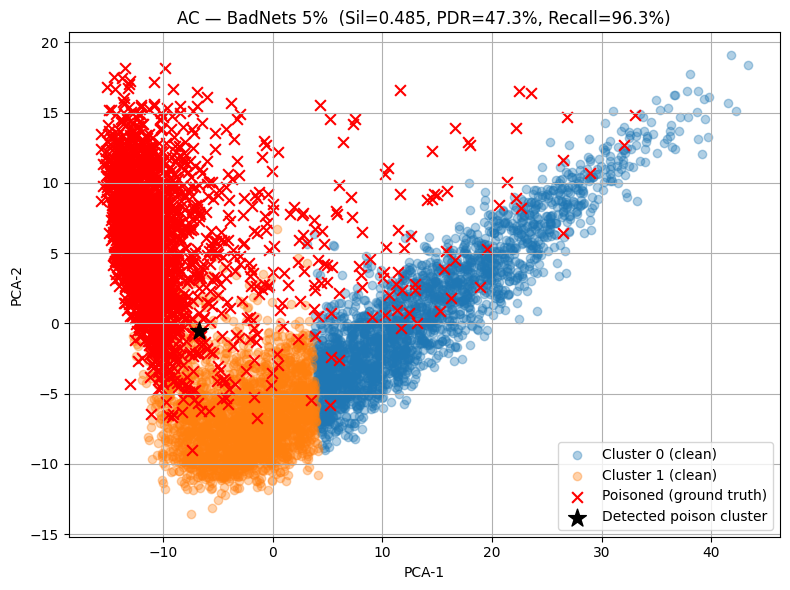

In [54]:
import matplotlib.pyplot as plt

# ensure clean_c matches current clusters length
clean_c       = ~poison_c  # poison_c must be same length as clusters (9339)
clean_cluster = 1 - pc

Xp = Xr  # already 2D

plt.figure(figsize=(8, 6))

plt.scatter(
    Xp[(clusters == clean_cluster) & clean_c, 0],
    Xp[(clusters == clean_cluster) & clean_c, 1],
    alpha=0.35, label=f"Cluster {clean_cluster} (clean)"
)
plt.scatter(
    Xp[(clusters == pc) & clean_c, 0],
    Xp[(clusters == pc) & clean_c, 1],
    alpha=0.35, label=f"Cluster {pc} (clean)"
)
plt.scatter(
    Xp[poison_c, 0], Xp[poison_c, 1],
    c="red", marker="x", s=60, label="Poisoned (ground truth)"
)
plt.scatter(
    Xp[clusters == pc, 0].mean(),
    Xp[clusters == pc, 1].mean(),
    c="black", marker="*", s=180, zorder=5, label="Detected poison cluster"
)

plt.title(f"AC — BadNets {int(POISON_RATE*100)}%  (Sil={sil:.3f}, PDR={PDR*100:.1f}%, Recall={recall*100:.1f}%)")
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.legend()
plt.grid(True)
plt.tight_layout()

plot_save_path = f"{DRIVE_ROOT}/ac_plots/ac_badnets_{int(POISON_RATE*100)}pct.png"
plt.savefig(plot_save_path, dpi=150, bbox_inches="tight")
print(f"Saved: {plot_save_path}")
plt.show()

Saved: /content/drive/MyDrive/ps-capstone/ac_plots/ac_badnets_5pct.png


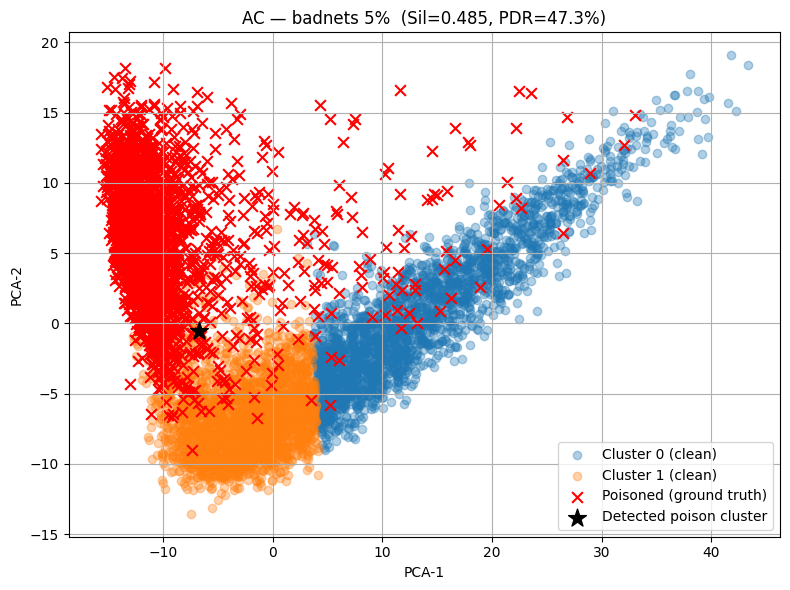

In [55]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce ICA-10D → PCA-2D for visualization (same as repo's plot_ac_results)
# Use ac_results from run_ac (ICA-based), not your PCA sweep
X_ica         = ac_results["reduced_acts"]       # ICA 10D
clusters      = ac_results["cluster_labels"]
poison_c      = ac_results["poison_flags_target"].astype(bool)
clean_c       = ~poison_c
pc            = ac_results["poison_cluster"]
clean_cluster = 1 - pc
sil           = ac_results["silhouette"]
PDR           = ac_results["PDR"]

Xp = PCA(n_components=2, random_state=SEED).fit_transform(X_ica)  # 10D → 2D

plt.figure(figsize=(8, 6))

plt.scatter(
    Xp[(clusters == 0) & clean_c, 0],
    Xp[(clusters == 0) & clean_c, 1],
    alpha=0.35, label="Cluster 0 (clean)"
)
plt.scatter(
    Xp[(clusters == 1) & clean_c, 0],
    Xp[(clusters == 1) & clean_c, 1],
    alpha=0.35, label="Cluster 1 (clean)"
)
plt.scatter(
    Xp[poison_c, 0], Xp[poison_c, 1],
    c="red", marker="x", s=60, label="Poisoned (ground truth)"
)
plt.scatter(
    Xp[clusters == pc, 0].mean(),
    Xp[clusters == pc, 1].mean(),
    c="black", marker="*", s=180, zorder=5, label="Detected poison cluster"
)

plt.title(f"AC — badnets {int(POISON_RATE*100)}%  (Sil={sil:.3f}, PDR={PDR:.1f}%)")
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.legend()
plt.grid(True)
plt.tight_layout()

plot_save_path = f"{DRIVE_ROOT}/ac_plots/ac_badnets_{int(POISON_RATE*100)}pct.png"
plt.savefig(plot_save_path, dpi=150, bbox_inches="tight")
print(f"Saved: {plot_save_path}")
plt.show()

In [56]:
unique, counts = np.unique(clusters, return_counts=True)
total = len(clusters)

suspicious_fraction = counts[pc] / total

print(f"Suspicious Fraction: {suspicious_fraction:.4f}  ({suspicious_fraction*100:.2f}%)")
print(f"Expected poison rate: {POISON_RATE*100:.1f}%")
print(f"Cluster sizes: Cluster 0 = {counts[0]}, Cluster 1 = {counts[1]}")
print(f"Detected poison cluster: {pc} ({counts[pc]} samples)")

Suspicious Fraction: 0.6713  (67.13%)
Expected poison rate: 5.0%
Cluster sizes: Cluster 0 = 2318, Cluster 1 = 4734
Detected poison cluster: 1 (4734 samples)


In [57]:
import numpy as np
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ===== Pull from your ac_results (same as your 2D code) =====
X_ica   = ac_results["reduced_acts"]             # ICA (likely 10D)
clusters= ac_results["cluster_labels"]
poison_c= ac_results["poison_flags_target"].astype(bool)
clean_c = ~poison_c
pc      = ac_results["poison_cluster"]           # detected poison cluster
sil     = ac_results["silhouette"]
PDR     = ac_results["PDR"]

# ===== Safe 3D reduction (auto-fallback if dims < 3) =====
n_samples, n_features = X_ica.shape
if n_features >= 3:
    X3 = PCA(n_components=3, random_state=SEED).fit_transform(X_ica)
    is_3d = True
else:
    X3 = PCA(n_components=2, random_state=SEED).fit_transform(X_ica)
    is_3d = False

# ===== Hover text (nice for demo) =====
hover_text = [
    f"idx={i} | cluster={clusters[i]} | poison={int(poison_c[i])}"
    for i in range(len(clusters))
]

# ===== Masks =====
m0 = (clusters == 0)
m1 = (clusters == 1)
mp = poison_c

# ===== Cluster center (detected poison cluster) =====
center = X3[clusters == pc].mean(axis=0)

# ===== Build traces =====
if is_3d:
    trace_c0 = go.Scatter3d(
        x=X3[m0 & clean_c, 0], y=X3[m0 & clean_c, 1], z=X3[m0 & clean_c, 2],
        mode='markers',
        marker=dict(size=3, color='royalblue', opacity=0.35),
        name='Cluster 0 (clean)',
        text=[hover_text[i] for i in np.where(m0 & clean_c)[0]],
        hoverinfo='text'
    )
    trace_c1 = go.Scatter3d(
        x=X3[m1 & clean_c, 0], y=X3[m1 & clean_c, 1], z=X3[m1 & clean_c, 2],
        mode='markers',
        marker=dict(size=3, color='orange', opacity=0.35),
        name='Cluster 1 (clean)',
        text=[hover_text[i] for i in np.where(m1 & clean_c)[0]],
        hoverinfo='text'
    )
    trace_poison = go.Scatter3d(
        x=X3[mp, 0], y=X3[mp, 1], z=X3[mp, 2],
        mode='markers',
        marker=dict(size=6, color='crimson', symbol='x'),
        name='Poisoned (GT)',
        text=[hover_text[i] for i in np.where(mp)[0]],
        hoverinfo='text'
    )
    trace_center = go.Scatter3d(
        x=[center[0]], y=[center[1]], z=[center[2]],
        mode='markers',
        marker=dict(size=12, color='black', symbol='star'),
        name='Detected poison cluster'
    )

    fig = go.Figure(data=[trace_c0, trace_c1, trace_poison, trace_center])

    fig.update_layout(
        title=f"AC (3D PCA) — badnets {int(POISON_RATE*100)}%<br>"
              f"Sil={sil:.3f}, PDR={PDR:.1f}%",
        scene=dict(
            xaxis_title='PC1',
            yaxis_title='PC2',
            zaxis_title='PC3',
            bgcolor='white'
        ),
        legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.7)'),
        margin=dict(l=0, r=0, b=0, t=50)
    )

else:
    # 2D fallback (if your ICA was only 2D)
    trace_c0 = go.Scatter(
        x=X3[m0 & clean_c, 0], y=X3[m0 & clean_c, 1],
        mode='markers',
        marker=dict(size=4, color='royalblue', opacity=0.35),
        name='Cluster 0 (clean)'
    )
    trace_c1 = go.Scatter(
        x=X3[m1 & clean_c, 0], y=X3[m1 & clean_c, 1],
        mode='markers',
        marker=dict(size=4, color='orange', opacity=0.35),
        name='Cluster 1 (clean)'
    )
    trace_poison = go.Scatter(
        x=X3[mp, 0], y=X3[mp, 1],
        mode='markers',
        marker=dict(size=6, color='crimson', symbol='x'),
        name='Poisoned (GT)'
    )
    trace_center = go.Scatter(
        x=[center[0]], y=[center[1]],
        mode='markers',
        marker=dict(size=12, color='black', symbol='star'),
        name='Detected poison cluster'
    )

    fig = go.Figure(data=[trace_c0, trace_c1, trace_poison, trace_center])

    fig.update_layout(
        title=f"AC (2D PCA fallback) — badnets {int(POISON_RATE*100)}%<br>"
              f"Sil={sil:.3f}, PDR={PDR:.1f}%",
        xaxis_title='PC1',
        yaxis_title='PC2',
        margin=dict(l=0, r=0, b=0, t=50)
    )

# ===== Show + Save =====
fig.show()

# Save interactive HTML to Drive (same folder idea as your PNG)
html_save_path = f"{DRIVE_ROOT}/ac_plots/ac_badnets_{int(POISON_RATE*100)}pct_3d.html"
fig.write_html(html_save_path)
print(f"Saved interactive plot: {html_save_path}")

Saved interactive plot: /content/drive/MyDrive/ps-capstone/ac_plots/ac_badnets_5pct_3d.html
